<a class="anchor" id="0"></a>
# **Random Forest Classifier Tutorial**

Random Forest is a supervised machine learning algorithm which is based on ensemble learning. In this kernel, we build two Random Forest Classifier models to predict the safety of the car, one with 10 decision-trees and another one with 100 decision-trees. The expected accuracy increases with number of decision-trees in the model. we have demonstrated the **feature selection process** using the Random Forest model to find only the important features, rebuild the model using these features and see its effect on accuracy.


# **1. Introduction to Random Forest algorithm** <a class="anchor" id="1"></a>

Random forest is a supervised learning algorithm. It has two variations – one is used for classification problems and other is used for regression problems. It is one of the most flexible and easy to use algorithm. It creates decision trees on the given data samples, gets prediction from each tree and selects the best solution by means of voting. It is also a pretty good indicator of feature importance.


Random forest algorithm combines multiple decision-trees, resulting in a forest of trees, hence the name `Random Forest`. In the random forest classifier, the higher the number of trees in the forest results in higher accuracy.



# **2. Random Forest algorithm intuition** <a class="anchor" id="2"></a>

Random forest algorithm intuition can be divided into two stages.


In the first stage, we randomly select “k” features out of total `m` features and build the random forest. In the first stage, we proceed as follows:-

1.	Randomly select `k` features from a total of `m` features where `k < m`.
2.	Among the `k` features, calculate the node `d` using the best split point.
3.	Split the node into daughter nodes using the best split.
4.	Repeat 1 to 3 steps until `l` number of nodes has been reached.
5.	Build forest by repeating steps 1 to 4 for `n` number of times to create `n` number of trees.


In the second stage, we make predictions using the trained random forest algorithm.

1.	We take the test features and use the rules of each randomly created decision tree to predict the outcome and stores the predicted outcome.
2.	Then, we calculate the votes for each predicted target.
3.	Finally, we consider the high voted predicted target as the final prediction from the random forest algorithm.


### Random Forest algorithm intuition

![Random Forest](https://i.ytimg.com/vi/goPiwckWE9M/maxresdefault.jpg)

# **3. Advantages and disadvantages of Random Forest algorithm** <a class="anchor" id="3"></a>

The advantages of Random forest algorithm are as follows:-

1.	Random forest algorithm can be used to solve both classification and regression problems.
2.	It is considered as very accurate and robust model because it uses large number of decision-trees to make predictions.
3.	Random forests takes the average of all the predictions made by the decision-trees, which cancels out the biases. So, it does not suffer from the overfitting problem.
4.	Random forest classifier can handle the missing values. There are two ways to handle the missing values. First is to use median values to replace continuous variables and second is to compute the proximity-weighted average of missing values.
5.	Random forest classifier can be used for feature selection. It means selecting the most important features out of the available features from the training dataset.


The disadvantages of Random Forest algorithm are listed below:-


1.	The biggest disadvantage of random forests is its computational complexity. Random forests is very slow in making predictions because large number of decision-trees are used to make predictions. All the trees in the forest have to make a prediction for the same input and then perform voting on it. So, it is a time-consuming process.
2.	The model is difficult to interpret as compared to a decision-tree, where we can easily make a prediction as compared to a decision-tree.


# **4. Feature selection with Random Forests** <a class="anchor" id="4"></a>

Random forests algorithm can be used for feature selection process. This algorithm can be used to rank the importance of variables in a regression or classification problem.


We measure the variable importance in a dataset by fitting the random forest algorithm to the data. During the fitting process, the out-of-bag error for each data point is recorded and averaged over the forest.


The importance of the j-th feature was measured after training. The values of the j-th feature were permuted among the training data and the out-of-bag error was again computed on this perturbed dataset. The importance score for the j-th feature is computed by averaging the difference in out-of-bag error before and after the permutation over all trees. The score is normalized by the standard deviation of these differences.


Features which produce large values for this score are ranked as more important than features which produce small values. Based on this score, we will choose the most important features and drop the least important ones for model building.


# **5. Difference between Random Forests and Decision Trees** <a class="anchor" id="5"></a>

We will compare random forests with decision-trees. Some salient features of comparison are as follows:-

1. Random forests is a set of multiple decision-trees.

2. Decision-trees are computationally faster as compared to random forests.

3. Deep decision-trees may suffer from overfitting. Random forest prevents overfitting by creating trees on random subset of data.

4. Random forest is difficult to interpret. But, a decision-tree is easily interpretable and can be converted to rules.

# **6. Relationship to nearest neighbours** <a class="anchor" id="6"></a>

A relationship between random forests and the k-nearest neighbours algorithm was pointed out by Lin and Jeon in 2002. It turns out that both can be viewed as so-called weighted neighbourhoods schemes. These are models built from a training set that make predictions for new points by looking at the neighbourhood of the point, formalized by a weight function.

# **7. Import libraries** <a class="anchor" id="7"></a>


In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # statistical data visualization
%matplotlib inline

In [2]:
import warnings

warnings.filterwarnings('ignore')

# **8. Import dataset** <a class="anchor" id="8"></a>

In [3]:
data_path = '/content/car_evaluation.csv'

df = pd.read_csv(data_path, header=None)

# **9. Exploratory data analysis** <a class="anchor" id="9"></a>


Now, we will explore the data to gain insights about the data.

In [4]:
# view dimensions of dataset

df.shape

(1728, 7)

We can see that there are 1728 instances and 7 variables in the data set.

### View top 5 rows of dataset

In [5]:
# preview the dataset

df.head()

,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


### Rename column names

We can see that the dataset does not have proper column names. The columns are merely labelled as 0,1,2.... and so on. We should give proper names to the columns. We will do it as follows:-

In [6]:
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df.columns = col_names
col_names

['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

In [7]:
# let's again preview the dataset

df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [8]:
df.tail()

,buying,maint,doors,persons,lug_boot,safety,class
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good
1727,low,low,5more,more,big,high,vgood


We can see that the column names are renamed. Now, the columns have meaningful names.

### View summary of dataset

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


### Frequency distribution of values in variables

Now, we will check the frequency counts of categorical variables.

In [10]:
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
for col in col_names:
    print(df[col].value_counts())


buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
persons
2       576
4       576
more    576
Name: count, dtype: int64
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
safety
low     576
med     576
high    576
Name: count, dtype: int64
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


We can see that the `doors` and `persons` are categorical in nature. So, we will treat them as categorical variables.

### Summary of variables


- There are 7 variables in the dataset. All the variables are of categorical data type.


- These are given by `buying`, `maint`, `doors`, `persons`, `lug_boot`, `safety` and `class`.


- `class` is the target variable.

### Explore `class` variable

In [11]:
df['class'].value_counts()

,count
class,
unacc,1210
acc,384
good,69
vgood,65


The `class` target variable is ordinal in nature.

### Missing values in variables

In [12]:
# check missing values in variables
df.isnull().sum()

,0
buying,0
maint,0
doors,0
persons,0
lug_boot,0
safety,0
class,0


We can see that there are no missing values in the dataset. we have checked the frequency distribution of values previously. It also confirms that there are no missing values in the dataset.

# **10. Declare feature vector and target variable** <a class="anchor" id="10"></a>

In [13]:
X = df.drop(['class'], axis=1)
y = df['class']

# **11. Split data into separate training and test set** <a class="anchor" id="11"></a>

In [14]:
# split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

In [15]:
# check the shape of X_train and X_test

X_train.shape, X_test.shape

((1157, 6), (571, 6))

# **12. Feature Engineering** <a class="anchor" id="12"></a>

**Feature Engineering** is the process of transforming raw data into useful features that help us to understand our model better and increase its predictive power. we will carry out feature engineering on different types of variables.


First, we will check the data types of variables again.

In [16]:
# check data types in X_train
X_train.dtypes

,0
buying,object
maint,object
doors,object
persons,object
lug_boot,object
safety,object


### Encode categorical variables


Now, we will encode the categorical variables.

In [17]:
X_train.head()

,buying,maint,doors,persons,lug_boot,safety
48,vhigh,vhigh,3,more,med,low
468,high,vhigh,3,4,small,low
155,vhigh,high,3,more,small,high
1721,low,low,5more,more,small,high
1208,med,low,2,more,small,high


We can see that all  the variables are ordinal categorical data type.

## How Ordinal Encoding Works

### What is Ordinal Encoding?

Ordinal encoding is a technique used to convert categorical data into numeric values, where each category is mapped to an integer. The key point here is that the encoding reflects the ordinal nature of the categories — that is, the order of the categories matters (e.g., "low" < "med" < "high" < "vhigh").

However, **many libraries** (such as `sklearn`'s `OrdinalEncoder`) **do not infer the semantic order of the categories** automatically. By default, the encoder will either:

- Assign integers based on the order it encounters the categories (first seen gets `0`, second seen gets `1`, and so on).
- Or, it will assign integers based on alphabetical order of the category labels.

This means the encoder does not inherently "understand" that **"low" < "med" < "high" < "vhigh"** unless explicitly told. It just sees strings and assigns numbers according to its internal logic.

### Why This Can Be a Problem

Because the encoder does not automatically infer the correct order, **the mapping might not match the natural order you expect**.

For example, if your data looks like this:

- `"vhigh"`, `"high"`, `"low"`, `"med"`

The encoder might assign them as:

- `vhigh → 1`
- `high → 2`
- `low → 3`
- `med → 4`

This is **incorrect**, as the encoder’s internal order doesn't follow the logical or semantic sequence of the categories.

In this case, **"vhigh" got 1** and **"med" got 4** because the encoder mapped the categories based on its internal order, not the correct semantic order of the categories.

### How to Fix This

To ensure proper ordinal encoding, we need to explicitly define the order of the categories:

1. **Using `sklearn`'s `OrdinalEncoder` with predefined categories**  
   You can pass a list of categories in the correct order using the `categories` argument, like so:

   ```python
   from sklearn.preprocessing import OrdinalEncoder

   encoder = OrdinalEncoder(categories=[['low', 'med', 'high', 'vhigh']])
   encoded_data = encoder.fit_transform(data)


In [18]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 3.6 MB/s eta 0:00:00


In [19]:
# import category encoders
import category_encoders as ce

In [20]:
ordinal_mapping = [
    {'col': 'buying', 'mapping': {'low':1, 'med':2, 'high':3, 'vhigh':4}},
    {'col': 'maint', 'mapping': {'low':1, 'med':2, 'high':3, 'vhigh':4}},
    {'col': 'doors', 'mapping': {'2':1, '3':2, '4':3, '5more':4}},
    {'col': 'persons', 'mapping': {'2':1, '4':2, 'more':3}},
    {'col': 'lug_boot', 'mapping': {'small':1, 'med':2, 'big':3}},
    {'col': 'safety', 'mapping': {'low':1, 'med':2, 'high':3}},
]

In [23]:
encoder = ce.OrdinalEncoder(mapping=ordinal_mapping, cols=[m['col'] for m in ordinal_mapping])
X_train = encoder.fit_transform(X_train)
X_test  = encoder.transform(X_test)

In [24]:
X_train.head()

,buying,maint,doors,persons,lug_boot,safety
48,4,4,2,3,2,1
468,3,4,2,2,1,1
155,4,3,2,3,1,3
1721,1,1,4,3,1,3
1208,2,1,1,3,1,3


In [25]:
X_test.head()

,buying,maint,doors,persons,lug_boot,safety
599,3,3,3,1,2,3
1201,2,1,1,2,2,2
628,3,3,4,1,3,2
1498,1,3,4,2,2,2
1263,2,1,3,3,2,1


## Issue with Encoding Order

It seems the encoder did not encode the data in the natural order we would normally expect (low < med < high < vhigh). From the samples, the mapping appears to be:

- `buying: vhigh → 1, high → 2, low → 3, med → 4`

This is **not** the ordinal ranking we typically want. The order of encoding should follow the natural hierarchy, not the reverse.

### What we should do

We need to explicitly define the correct order of categories (or inspect the encoder’s mapping) and then re-encode the data accordingly.

### How to Check What the Encoder Did

We can check what the encoder has done by examining the encoding mapping. This will help you understand why the order might not be as expected and ensure you are encoding the values in the correct order.

### Why This Matters

Incorrect encoding can lead to misleading interpretations and poor model performance. The way the categories are mapped directly impacts how algorithms will treat them.

### How to Fix It

Here are two safe options to correctly encode the data:

1. **Using `category_encoders` with explicit mapping**  
   This allows us to define the order of categories ourself, ensuring that the encoder follows the desired sequence.
   
2. **Using `sklearn`'s `OrdinalEncoder` with predefined categories**  
   You can use the `OrdinalEncoder` and pass a list of categories in the correct order to the `categories` argument. This ensures the encoder respects the natural order.

By using one of these methods, you can re-encode your data correctly and avoid the issue of reversed or misaligned categories.


In [ ]:
## Old code results to compare



# # encode categorical variables with ordinal encoding
# encoder = ce.OrdinalEncoder(cols=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'])
# X_train = encoder.fit_transform(X_train)
# X_test = encoder.transform(X_test)

In [ ]:
## Old code results to compare

# X_train.head()

,buying,maint,doors,persons,lug_boot,safety
48,1,1,1,1,1,1
468,2,1,1,2,2,1
155,1,2,1,1,2,2
1721,3,3,2,1,2,2
1208,4,3,3,1,2,2


In [ ]:
## Old code results to compare


# X_test.head()

,buying,maint,doors,persons,lug_boot,safety
599,2,2,4,3,1,2
1201,4,3,3,2,1,3
628,2,2,2,3,3,3
1498,3,2,2,2,1,3
1263,4,3,4,1,1,1


We now have training and test set ready for model building.

# **13. Random Forest Classifier model with default parameters** <a class="anchor" id="13"></a>

In [26]:
# import Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

# instantiate the classifier
rfc = RandomForestClassifier(n_estimators=10, random_state=0)

# fit the model
rfc.fit(X_train, y_train)

# Predict the Test set results
y_pred = rfc.predict(X_test)

# Check accuracy score
from sklearn.metrics import accuracy_score
print('Model accuracy score with 10 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with 10 decision-trees : 0.9597


Here, **y_test** are the true class labels and **y_pred** are the predicted class labels in the test-set.

Here, I have build the Random Forest Classifier model with default parameter of `n_estimators = 10`. So, I have used 10 decision-trees to build the model. Now, I will increase the number of decision-trees and see its effect on accuracy.

# **14. Random Forest Classifier model with parameter n_estimators=100** <a class="anchor" id="14"></a>

In [27]:
# instantiate the classifier with n_estimators = 100
rfc_100 = RandomForestClassifier(n_estimators=100, random_state=0)

# fit the model to the training set
rfc_100.fit(X_train, y_train)

# Predict on the test set results
y_pred_100 = rfc_100.predict(X_test)

# Check accuracy score
print('Model accuracy score with 100 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred_100)))

Model accuracy score with 100 decision-trees : 0.9650


The model accuracy score with 10 decision-trees is 0.9247 but the same with 100 decision-trees is 0.9457. So, as expected accuracy increases with number of decision-trees in the model.

# **15. Find important features with Random Forest model** <a class="anchor" id="15"></a>


Until now, we have used all the features given in the model. Now, we will select only the important features, build the model using these features and see its effect on accuracy.


First, we will create the Random Forest model as follows:-

In [28]:
# create the classifier with n_estimators = 100
clf = RandomForestClassifier(n_estimators=100, random_state=0)

# fit the model to the training set
clf.fit(X_train, y_train)


RandomForestClassifier(random_state=0)

Now, we will use the feature importance variable to see feature importance scores.

In [29]:
# view the feature scores
feature_scores = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
feature_scores

,0
safety,0.305071
persons,0.234537
buying,0.161964
maint,0.148404
lug_boot,0.086875
doors,0.063149


We can see that the most important feature is `safety` and least important feature is `doors`.

# **16. Visualize feature scores of the features** <a class="anchor" id="16"></a>

Now, we will visualize the feature scores with matplotlib and seaborn.

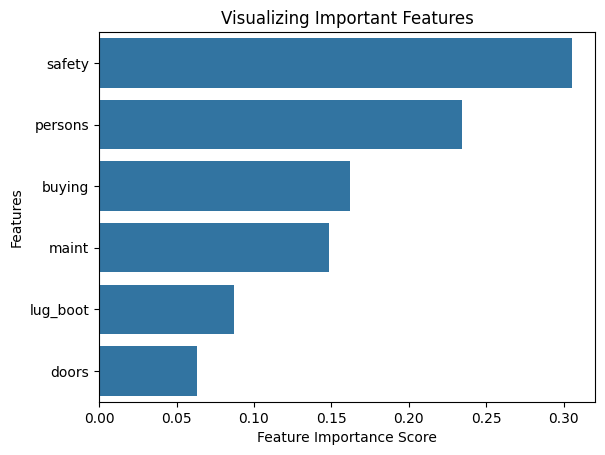

In [30]:
# Creating a seaborn bar plot
sns.barplot(x=feature_scores, y=feature_scores.index)

# Add labels to the graph
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')

# Add title to the graph
plt.title("Visualizing Important Features")

# Visualize the graph
plt.show()

# **17. Build Random Forest model on selected features** <a class="anchor" id="17"></a>

Now, we will drop the least important feature `doors` from the model, rebuild the model and check its effect on accuracy.

In [31]:
# declare feature vector and target variable
X = df.drop(['class', 'doors'], axis=1)
y = df['class']

In [32]:
# split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

Now, we will build the random forest model and check accuracy.

In [33]:
# encode categorical variables with ordinal encoding
encoder = ce.OrdinalEncoder(cols=['buying', 'maint', 'persons', 'lug_boot', 'safety'])

X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)

In [34]:
# instantiate the classifier with n_estimators = 100
clf = RandomForestClassifier(n_estimators=10, random_state=0)

# fit the model to the training set
clf.fit(X_train, y_train)

# Predict on the test set results
y_pred = clf.predict(X_test)

# Check accuracy score
print('Model accuracy score with doors variable removed : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))


Model accuracy score with doors variable removed : 0.9264


We have removed the `doors` variable from the model, rebuild it and checked its accuracy. The accuracy of the model with `doors` variable removed is 0.9264. The accuracy of the model with all the variables taken into account is 0.9247. So, we can see that the model accuracy has been improved with `doors` variable removed from the model.

Furthermore, the second least important model is `lug_boot`. If we remove it from the model and rebuild the model, then the accuracy was found to be 0.8546. It is a significant drop in the accuracy. So, we will not drop it from the model.

Now, based on the above analysis we can conclude that our classification model accuracy is very good. Our model is doing a very good job in terms of predicting the class labels.


But, it does not give the underlying distribution of values. Also, it does not tell anything about the type of errors our classifer is making.


We have another tool called `Confusion matrix` that comes to our rescue.

# **18. Confusion matrix** <a class="anchor" id="18"></a>

A confusion matrix is a tool for summarizing the performance of a classification algorithm. A confusion matrix will give us a clear picture of classification model performance and the types of errors produced by the model. It gives us a summary of correct and incorrect predictions broken down by each category. The summary is represented in a tabular form.


Four types of outcomes are possible while evaluating a classification model performance. These four outcomes are described below:-


**True Positives (TP)** – True Positives occur when we predict an observation belongs to a certain class and the observation actually belongs to that class.


**True Negatives (TN)** – True Negatives occur when we predict an observation does not belong to a certain class and the observation actually does not belong to that class.


**False Positives (FP)** – False Positives occur when we predict an observation belongs to a    certain class but the observation actually does not belong to that class. This type of error is called **Type I error.**



**False Negatives (FN)** – False Negatives occur when we predict an observation does not belong to a certain class but the observation actually belongs to that class. This is a very serious error and it is called **Type II error.**



These four outcomes are summarized in a confusion matrix given below.


In [35]:
# Print the Confusion Matrix and slice it into four pieces
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix\n\n', cm)

Confusion matrix

 [[107   8   7   7]
 [  0  17   1   2]
 [ 10   0 387   0]
 [  3   4   0  18]]


#### Ploting the confusion matrix

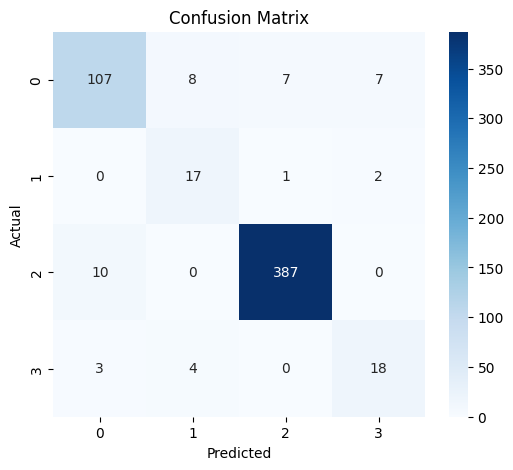

In [36]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# **19. Classification Report** <a class="anchor" id="19"></a>

**Classification report** is another way to evaluate the classification model performance. It displays the  **precision**, **recall**, **f1** and **support** scores for the model. I have described these terms in later.

We can print a classification report as follows:-

In [37]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         acc       0.89      0.83      0.86       129
        good       0.59      0.85      0.69        20
       unacc       0.98      0.97      0.98       397
       vgood       0.67      0.72      0.69        25

    accuracy                           0.93       571
   macro avg       0.78      0.84      0.81       571
weighted avg       0.93      0.93      0.93       571



# **20. Results and conclusion** <a class="anchor" id="20"></a>

1.	In this project, I build a Random Forest Classifier to predict the safety of the car. I build two models, one with 10 decision-trees and another one with 100 decision-trees.
2.	The model accuracy score with 10 decision-trees is 0.9247 but the same with 100 decision-trees is 0.9457. So, as expected accuracy increases with number of decision-trees in the model.
3.	I have used the Random Forest model to find only the important features, build the model using these features and see its effect on accuracy. The most important feature is `safety` and least important feature is `doors`.
4.	I have removed the `doors` variable from the model, rebuild it and checked its accuracy. The accuracy of the model with `doors` variable removed is 0.9264. The accuracy of the model with all the variables taken into account is 0.9247. So, we can see that the model accuracy has been improved with `doors` variable removed from the model.
5.	The second least important model is `lug_boot`. If I remove it from the model and rebuild the model, then the accuracy was found to be 0.8546. It is a significant drop in the accuracy. So, I will not drop it from the model.
6.	Confusion matrix and classification report are another tool to visualize the model performance. They yield good performance.



# **21. References** <a class="anchor" id="21"></a>

1. Hands on Machine Learning with Scikit-Learn and Tensorflow by Aurélién Géron

2. Introduction to Machine Learning with Python by Andreas C. Müller and Sarah Guido

3. https://en.wikipedia.org/wiki/Random_forest

4. https://www.datacamp.com/community/tutorials/random-forests-classifier-python

5. http://dataaspirant.com/2017/05/22/random-forest-algorithm-machine-learing/

6. https://stackabuse.com/random-forest-algorithm-with-python-and-scikit-learn/